# 🪐 EDA — Exoplanetas confirmados

Análisis exploratorio sobre los exoplanetas confirmados del [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/), usando el mismo pipeline de transformación del proyecto (`src/transform.py`) — las columnas calculadas acá (`habitability`, `planet_type`, `discovery_era`, etc.) son exactamente las que después expone la API y muestra el dashboard, así que las conclusiones de este notebook y las de la página deberían coincidir.

**Hilo conductor:** los exoplanetas confirmados que conocemos no son una muestra representativa del universo — son los que nuestra tecnología actual pudo detectar. Frente a las ~100 mil millones de estrellas de la Vía Láctea, ese sesgo de observación (hacia lo cercano, lo grande, lo que transita frente a su estrella) aparece una y otra vez en los datos. Este notebook busca mostrarlo con evidencia, sección por sección — ningún número de las conclusiones está escrito a mano, todos salen de `df` calculados en la celda de al lado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import sys
sys.path.append('..')
from src.transform import transform

plt.rcParams['figure.figsize'] = (10, 5)
COLOR = '#2a78d6'  # mismo azul que usa el dashboard de Streamlit

## Un vistazo a los datos

`transform()` corre el mismo pipeline raw → staging → mart que usa el proyecto (sin pasar por S3/dbt): consulta la API TAP de NASA en vivo y devuelve un DataFrame con una fila por planeta, ya con las clasificaciones calculadas (`habitability`, `planet_type`, `temp_habitability`, `spectral_type`, `discovery_era`).

In [3]:
df = transform()
print(f"{df.shape[0]} planetas, {df.shape[1]} columnas")
df.head()

6336 planetas, 31 columnas


,planet_name,star_name,num_stars,num_planets,num_moons,discovery_method,discovery_year,discovery_locale,discovery_facility,discovery_telescope,...,ra_deg,dec_deg,hz_inner,hz_outer,eff_distance,habitability,temp_habitability,planet_type,spectral_type,discovery_era
0,HD 80653 b,HD 80653,1,2,0,Transit,2020,Space,K2,0.95 m Kepler Telescope,...,140.339085,14.367869,0.956943,2.258386,0.016570,Muy cerca,hT - hyperthermoplanet,Super-Earth,G,Era TESS
1,K2-312 c,HD 80653,1,2,0,Radial Velocity,2023,Ground,Roque de los Muchachos Observatory,3.58 m Telescopio Nazionale Galileo,...,140.339085,14.367869,0.956943,2.258386,2.551514,Muy lejos,P - psychroplanet,Jovian-like,G,Era TESS
2,XO-2 S d,XO-2 S,2,4,0,Radial Velocity,2024,Ground,Multiple Observatories,Multiple Telescopes,...,117.030975,50.216907,0.650955,1.536255,5.482607,Muy lejos,hP - hypopsychroplanet,Jovian-like,G,Era TESS
3,Kepler-1808 b,Kepler-1808,1,1,0,Transit,2021,Space,Kepler,0.95 m Kepler Telescope,...,287.292474,39.383204,0.697993,1.647264,0.146700,Muy cerca,hT - hyperthermoplanet,Sub-Neptune,G,Era TESS
4,Kepler-418 b,Kepler-418,1,2,0,Transit,2014,Space,Kepler,0.95 m Kepler Telescope,...,294.433523,38.355473,0.852376,2.011608,0.400340,Muy cerca,hT - hyperthermoplanet,Jovian-like,G,Era Kepler


### Valores nulos

In [4]:
df.isnull().sum()

planet_name                0
star_name                  0
num_stars                  0
num_planets                0
num_moons                  0
discovery_method           0
discovery_year             0
discovery_locale           0
discovery_facility         0
discovery_telescope        0
discovery_instrument       0
orbital_period_days      344
semi_major_axis_au       428
eccentricity            1053
planet_radius_earth       50
equilibrium_temp_k       526
star_temp_k              297
star_radius_solar        321
star_mass_solar            9
star_luminosity_log      315
distance_pc               27
ra_deg                     0
dec_deg                    0
hz_inner                 315
hz_outer                 315
eff_distance            1123
habitability               0
temp_habitability          0
planet_type                0
spectral_type              0
discovery_era              0
dtype: int64

La mayor cantidad de nulos está en **eff_distance**, en gran parte porque para calcularla se usa **eccentricity** (casi 1000 nulos), y luego **equilibrium_temp_k** con 526. El resto de las columnas tiene menos del 5% de nulos, aceptable para este análisis: no se imputa nada, cada gráfico simplemente excluye (`.dropna()` puntual) las filas sin el dato que necesita en ese momento.

In [5]:
df.describe()

,num_stars,num_planets,num_moons,discovery_year,orbital_period_days,semi_major_axis_au,eccentricity,planet_radius_earth,equilibrium_temp_k,star_temp_k,star_radius_solar,star_mass_solar,star_luminosity_log,distance_pc,ra_deg,dec_deg,hz_inner,hz_outer,eff_distance
count,6336.000000,6336.000000,6336.0,6336.0,5.992000e+03,5908.000000,5283.000000,6286.000000,5810.000000,6039.000000,6015.000000,6327.000000,6021.000000,6309.000000,6336.000000,6336.000000,6021.000000,6021.000000,5213.000000
mean,1.101641,1.759785,0.0,2017.249369,7.144464e+04,15.545361,0.079915,5.851832,834.896141,5394.344078,1.489258,0.934775,-0.145965,704.333640,230.713841,17.549925,0.969003,2.286848,1.073830
std,0.339586,1.150985,0.0,5.119349,5.195691e+06,346.853588,0.153173,5.422517,496.619821,1727.761286,3.864738,0.387024,0.780740,1215.826842,92.611489,37.658890,1.768123,4.172771,12.420869
min,1.000000,1.000000,0.0,1992.0,9.070629e-02,0.004400,0.000000,0.309800,1.480000,415.000000,0.011500,0.009400,-6.090000,1.301190,0.185606,-89.471513,0.000676,0.001596,0.004408
25%,1.000000,1.000000,0.0,2014.0,4.308908e+00,0.052300,0.000000,1.850000,485.895000,4898.500000,0.770000,0.770000,-0.473960,101.251000,168.226736,-12.525095,0.434592,1.025636,0.052000
50%,1.000000,1.000000,0.0,2016.0,1.074551e+01,0.102750,0.000000,2.860000,755.625000,5544.000000,0.950000,0.940000,-0.079170,360.313000,284.335606,38.947263,0.684662,1.615802,0.099150
75%,1.000000,2.000000,0.0,2021.0,3.856275e+01,0.311250,0.092000,11.915990,1092.750000,5899.500000,1.249295,1.087500,0.310000,823.242000,293.086590,45.417147,1.071670,2.529142,0.249900
max,4.000000,8.000000,0.0,2026.0,4.020000e+08,19000.000000,0.950000,87.205870,7777.780000,57000.000000,88.475000,9.100000,3.800000,8500.000000,359.974984,88.829876,59.574618,140.596098,600.480000


## 1. Descubrimiento

### Cuándo se descubrieron

In [6]:
anio_min = int(df['discovery_year'].min())
df[df['discovery_year'] == anio_min][['planet_name', 'star_name', 'discovery_method']]

,planet_name,star_name,discovery_method
2144,PSR B1257+12 c,PSR B1257+12,Pulsar Timing
2259,PSR B1257+12 d,PSR B1257+12,Pulsar Timing


Los primeros exoplanetas confirmados datan de 1992 (arriba) — orbitan el púlsar **PSR B1257+12**, rebautizado informalmente "Lich" por la IAU en 2015. El año que guarda `discovery_year` es el de **confirmación**, no el de la primera observación: eso explica el salto que se ve en el siguiente gráfico entre 2014 y 2016, que no es un pico real de detecciones.

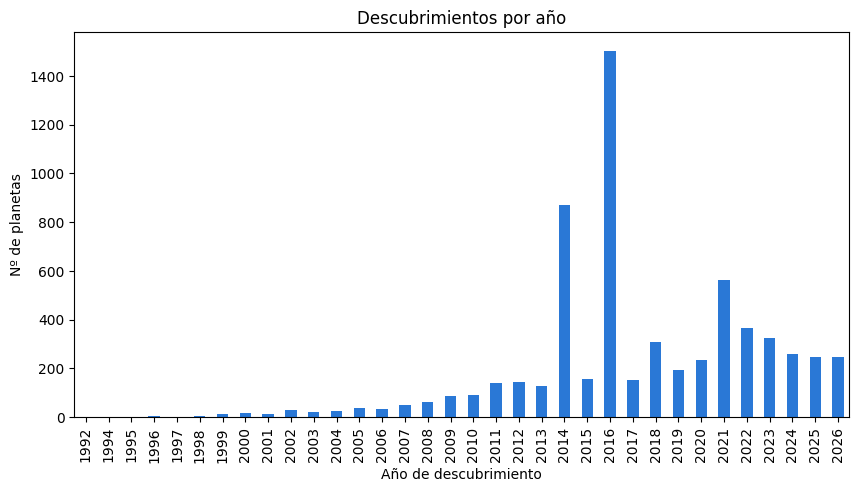

In [7]:
df['discovery_year'].value_counts().sort_index().plot(kind='bar', color=COLOR)
plt.xlabel('Año de descubrimiento')
plt.ylabel('Nº de planetas')
plt.title('Descubrimientos por año')
plt.show()

El salto de 2014-2016 coincide con la **era Kepler**: la misión publicó enormes lotes de datos acumulados e introdujo métodos de verificación estadística (validación por multiplicidad, 2014; el lote de 1284 planetas confirmados de una sola vez en mayo de 2016) que confirmaron miles de candidatos a la vez — de ahí que Kepler tenga, con diferencia, la mayor cantidad de descubrimientos.

### Cómo se descubrieron

In [8]:
conteo_metodo = df['discovery_method'].value_counts()
conteo_metodo

discovery_method
Transit                          4676
Radial Velocity                  1197
Microlensing                      282
Imaging                            98
Transit Timing Variations          40
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

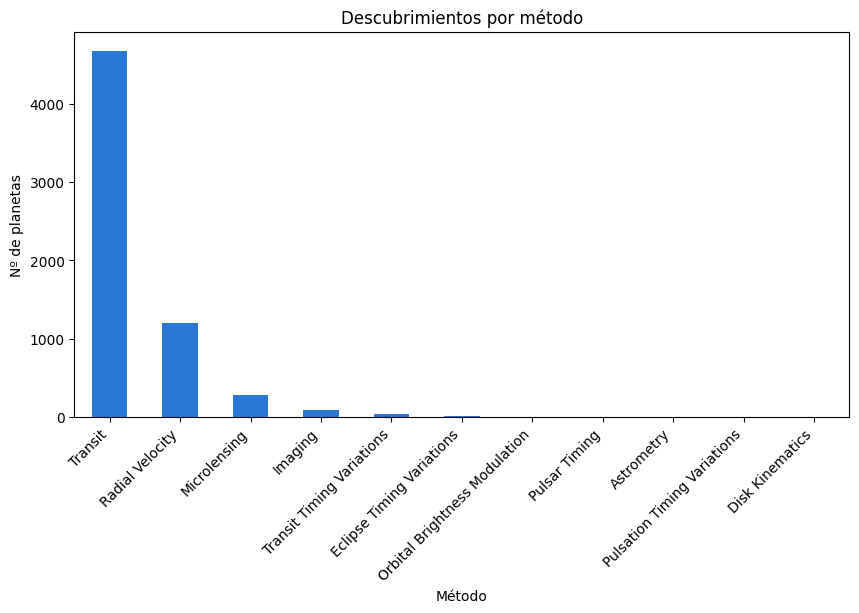

In [9]:
conteo_metodo.plot(kind='bar', color=COLOR)
plt.xlabel('Método')
plt.ylabel('Nº de planetas')
plt.title('Descubrimientos por método')
plt.xticks(rotation=45, ha='right')
plt.show()

El método de **tránsito** (observar cuándo cae el brillo de una estrella) domina claramente, seguido de **velocidad radial** (el "bamboleo" que produce un planeta en su estrella) y **microlente gravitacional** (una estrella con un planeta que pasa frente a otra más lejana y curva su luz). No es casualidad que sean justo los tres métodos más baratos de escalar a miles de estrellas a la vez — el orden de esta tabla es, en el fondo, un ranking de facilidad de detección, no de qué tan comunes son los planetas.

## 2. Distancia

### Los extremos

In [10]:
PC_A_ANIOS_LUZ = 3.26156

mas_lejano = df.loc[df['distance_pc'].idxmax()]
mas_cercano = df.loc[df['distance_pc'].idxmin()]

print(
    f"Más distante: {mas_lejano['planet_name']} a {mas_lejano['distance_pc']:,.0f} pc "
    f"(~{mas_lejano['distance_pc'] * PC_A_ANIOS_LUZ:,.0f} años luz), "
    f"orbitando {mas_lejano['star_name']}."
)
print(
    f"Más cercano: {mas_cercano['planet_name']} a {mas_cercano['distance_pc']:.2f} pc "
    f"(~{mas_cercano['distance_pc'] * PC_A_ANIOS_LUZ:.2f} años luz), "
    f"orbitando {mas_cercano['star_name']}."
)

Más distante: SWEEPS-4 b a 8,500 pc (~27,723 años luz), orbitando SWEEPS-4.
Más cercano: Proxima Cen d a 1.30 pc (~4.24 años luz), orbitando Proxima Cen.


### Distribución de distancias

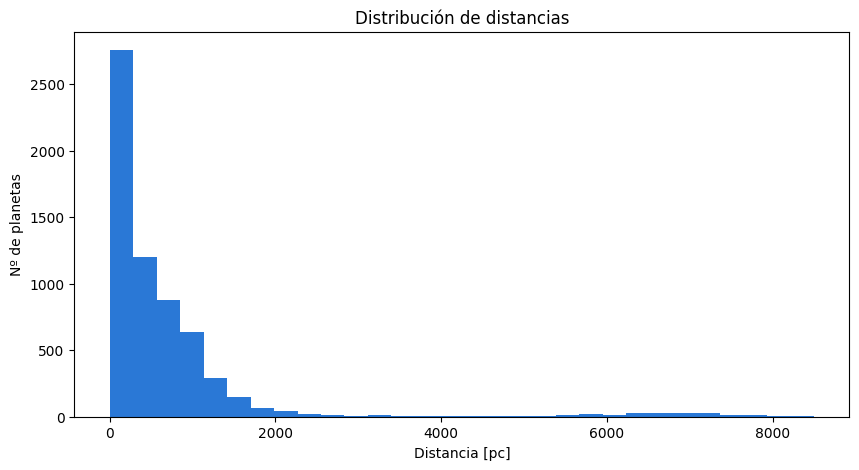

In [11]:
df['distance_pc'].dropna().plot(kind='hist', bins=30, color=COLOR)
plt.xlabel('Distancia [pc]')
plt.ylabel('Nº de planetas')
plt.title('Distribución de distancias')
plt.show()

La distribución está fuertemente concentrada cerca de la Tierra, con una cola larga hacia distancias mayores. Esto es sesgo de detección, no la distribución real de planetas en la galaxia: los sistemas cercanos dan una señal más fuerte para tránsito y velocidad radial, así que son los que más fácil se confirman.

## 3. Tamaño

### Los extremos

In [12]:
RADIO_JUPITER_TIERRA = 11.2
RADIO_MERCURIO_TIERRA = 0.383

mas_grande = df.loc[df['planet_radius_earth'].idxmax()]
mas_pequeno = df.loc[df['planet_radius_earth'].idxmin()]

print(
    f"Más grande: {mas_grande['planet_name']} — {mas_grande['planet_radius_earth']:.0f} radios "
    f"terrestres (~{mas_grande['planet_radius_earth'] / RADIO_JUPITER_TIERRA:.1f} veces Júpiter)."
)
print(
    f"Más pequeño: {mas_pequeno['planet_name']} — {mas_pequeno['planet_radius_earth']:.2f} radios "
    f"terrestres (~{mas_pequeno['planet_radius_earth'] / RADIO_MERCURIO_TIERRA:.0%} del radio de Mercurio)."
)

Más grande: V2376 Ori b — 87 radios terrestres (~7.8 veces Júpiter).
Más pequeño: Kepler-37 b — 0.31 radios terrestres (~81% del radio de Mercurio).


### Distribución por tipo de planeta

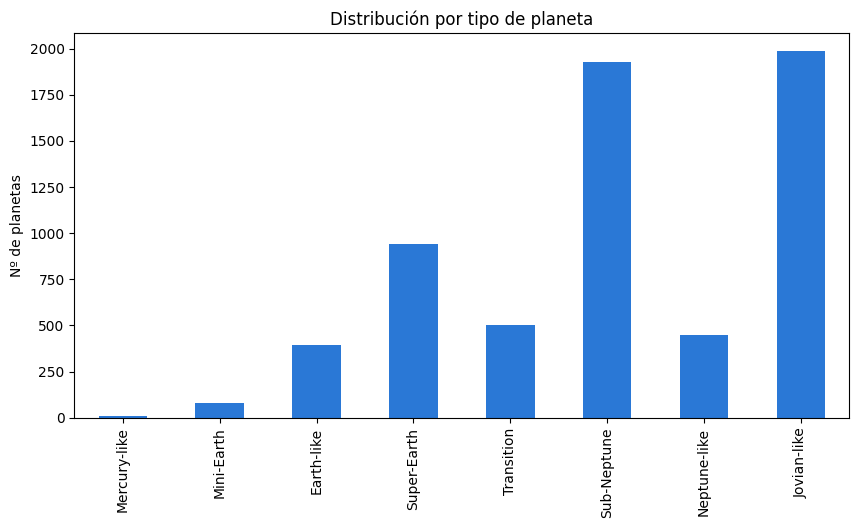

In [13]:
ORDEN_TAMANOS = [
    'Mercury-like', 'Mini-Earth', 'Earth-like', 'Super-Earth',
    'Transition', 'Sub-Neptune', 'Neptune-like', 'Jovian-like',
]

conteo_tipo = (
    df[df['planet_type'] != 'Desconocido']['planet_type']
    .value_counts()
    .reindex(ORDEN_TAMANOS)
)
conteo_tipo.plot(kind='bar', color=COLOR)
plt.xlabel('')
plt.ylabel('Nº de planetas')
plt.title('Distribución por tipo de planeta')
plt.show()

Los planetas grandes (sub-neptunos y jovianos) son los que más se descubren — otra vez sesgo de detección: un planeta grande bloquea más luz al transitar y produce un bamboleo más fuerte en su estrella, así que es más fácil de confirmar. No hay razón astrofísica para pensar que son, además, los más comunes.

## 4. Sistema

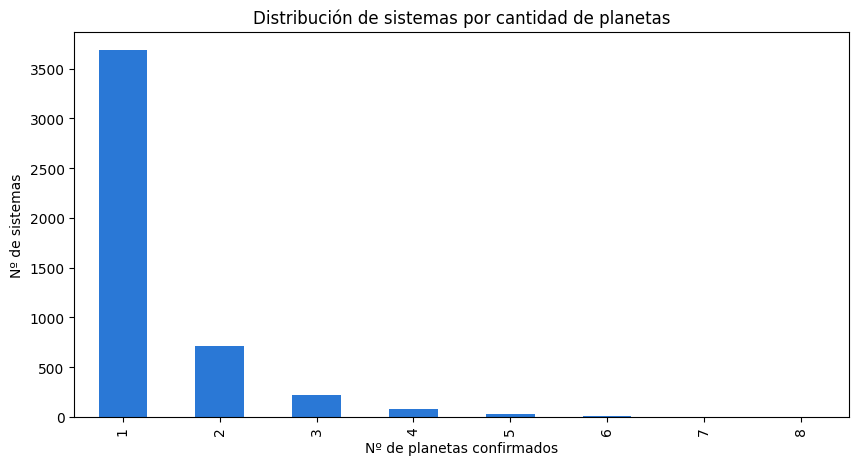

In [14]:
PLANETAS_SISTEMA_SOLAR = 8

# Un sistema = una fila por star_name (cada planeta del mismo sistema repite
# el mismo num_planets, así que hay que deduplicar antes de contar sistemas).
sistemas = df.drop_duplicates('star_name')
distribucion_sistema = sistemas['num_planets'].value_counts().sort_index()
max_planetas = int(distribucion_sistema.index.max())

distribucion_sistema.plot(kind='bar', color=COLOR)
plt.xlabel('Nº de planetas confirmados')
plt.ylabel('Nº de sistemas')
plt.title('Distribución de sistemas por cantidad de planetas')
plt.show()

In [15]:
comparacion = (
    'igual que' if max_planetas == PLANETAS_SISTEMA_SOLAR
    else ('más que' if max_planetas > PLANETAS_SISTEMA_SOLAR else 'menos que')
)
print(
    f"La mayoría de los sistemas tiene 1 solo exoplaneta confirmado "
    f"({distribucion_sistema.loc[1]} de {len(sistemas)} sistemas). "
    f"El máximo encontrado es {max_planetas}, {comparacion} en nuestro propio "
    f"sistema solar ({PLANETAS_SISTEMA_SOLAR})."
)

La mayoría de los sistemas tiene 1 solo exoplaneta confirmado (3685 de 4749 sistemas). El máximo encontrado es 8, igual que en nuestro propio sistema solar (8).


## 5. Habitabilidad

La clasificación usa la misma zona habitable "extendida" (`0.75·√L` a `1.77·√L` UA, con `L` la luminosidad estelar en unidades solares) que corre en `mart_planets.sql` — bajo este mismo criterio, la Tierra **y Marte** caen dentro de la zona habitable del Sol, así que la comparación de abajo usa 2 como referencia para nuestro propio sistema.

### Ranking de habitabilidad

In [16]:
PLANETAS_HABITABLES_SISTEMA_SOLAR = 2  # Tierra y Marte, con el mismo criterio de arriba

ranking_habitables = (
    df[df['habitability'] == 'Zona habitable']
    .groupby('star_name')
    .size()
    .sort_values(ascending=False)
)
ranking_habitables.head(10)

star_name
TRAPPIST-1    3
GJ 3293       2
TOI-700       2
Kepler-47     2
HD 34445      2
GJ 667 C      2
HD 45364      2
Kepler-296    2
GJ 180        2
GJ 1061       2
dtype: int64

In [17]:
max_habitables = int(ranking_habitables.max())
comparacion_hab = (
    'igual que' if max_habitables == PLANETAS_HABITABLES_SISTEMA_SOLAR
    else ('más que' if max_habitables > PLANETAS_HABITABLES_SISTEMA_SOLAR else 'menos que')
)
print(
    f"El sistema con más planetas en zona habitable es {ranking_habitables.idxmax()}, "
    f"con {max_habitables} — {comparacion_hab} el nuestro, que tiene "
    f"{PLANETAS_HABITABLES_SISTEMA_SOLAR} (Tierra y Marte)."
)

El sistema con más planetas en zona habitable es TRAPPIST-1, con 3 — más que el nuestro, que tiene 2 (Tierra y Marte).


### Distribución por habitabilidad

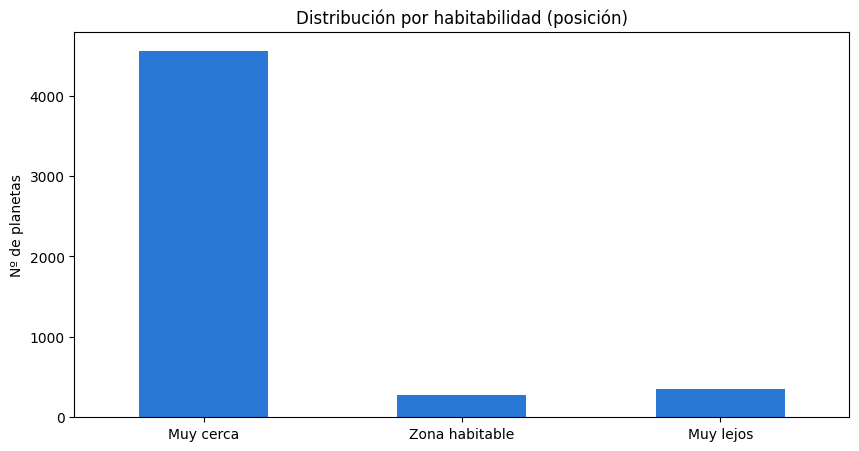

In [18]:
ORDEN_HABITABILIDAD = ['Muy cerca', 'Zona habitable', 'Muy lejos']

(
    df[df['habitability'] != 'Desconocido']['habitability']
    .value_counts()
    .reindex(ORDEN_HABITABILIDAD)
    .plot(kind='bar', color=COLOR)
)
plt.xlabel('')
plt.ylabel('Nº de planetas')
plt.title('Distribución por habitabilidad (posición)')
plt.xticks(rotation=0)
plt.show()

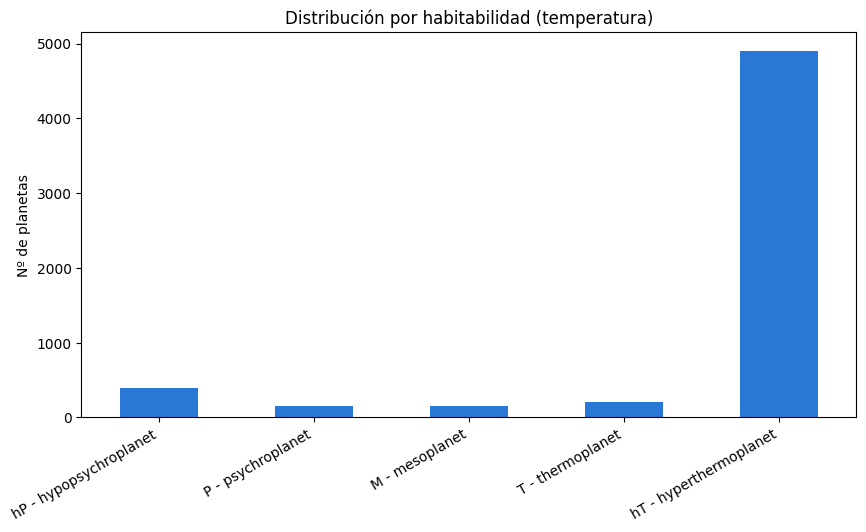

In [19]:
ORDEN_TEMP_HABITABILIDAD = [
    'hP - hypopsychroplanet', 'P - psychroplanet', 'M - mesoplanet',
    'T - thermoplanet', 'hT - hyperthermoplanet',
]

(
    df[df['temp_habitability'] != 'Desconocido']['temp_habitability']
    .value_counts()
    .reindex(ORDEN_TEMP_HABITABILIDAD)
    .plot(kind='bar', color=COLOR)
)
plt.xlabel('')
plt.ylabel('Nº de planetas')
plt.title('Distribución por habitabilidad (temperatura)')
plt.xticks(rotation=30, ha='right')
plt.show()

La mayoría de los planetas detectados están "Muy cerca" de su estrella y clasifican como "hT - hyperthermoplanet" (≥ 100 °C) — otra vez el mismo sesgo: los planetas calientes y cercanos son los más fáciles de encontrar por tránsito y velocidad radial, no los más comunes.

## 6. Conclusión

Todas las secciones anteriores muestran la misma historia desde un ángulo distinto: nuestros métodos de detección no son suficientes, y lo que llamamos "el catálogo de exoplanetas confirmados" es, en gran medida, un catálogo de lo que es fácil de detectar. Los planetas más fáciles de encontrar son los grandes, poco distantes y cercanos a su estrella — los llamados "júpiters calientes" — porque producen la señal más fuerte para tránsito y velocidad radial, los dos métodos que dominan el catálogo.

Eso genera un sesgo real si no se lo tiene en cuenta: ¿cuánto nos estamos perdiendo? Posiblemente haya muchos más planetas, e incluso lunas y asteroides, alrededor de estrellas lejanas, con tecnología actual todavía indetectables — de la misma forma que nuestro propio sistema solar tiene una variedad de cuerpos que un observador externo, con estos mismos métodos, difícilmente podría confirmar todos.

Recién estamos empezando en la detección de exoplanetas. Todavía falta mucho para tener un catálogo que sea una muestra representativa del universo, y no solo de lo que alcanzamos a ver.